In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/cardio_train.csv', sep=';')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (70000, 13)

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
# Check column names and data types
print("Columns and Data Types:")
print(df.info())

Columns and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None


In [3]:
# Basic statistics
print("Basic Statistics:")
df.describe()

Basic Statistics:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# Check for unrealistic values
print("Blood Pressure Range:")
print("Systolic (ap_hi):", df['ap_hi'].min(), "to", df['ap_hi'].max())
print("Diastolic (ap_lo):", df['ap_lo'].min(), "to", df['ap_lo'].max())

print("\nAge Range (in years):")
print(df['age'].min()//365, "to", df['age'].max()//365)

print("\nHeight Range:")
print(df['height'].min(), "to", df['height'].max(), "cm")

print("\nWeight Range:")
print(df['weight'].min(), "to", df['weight'].max(), "kg")

Blood Pressure Range:
Systolic (ap_hi): -150 to 16020
Diastolic (ap_lo): -70 to 11000

Age Range (in years):
29 to 64

Height Range:
55 to 250 cm

Weight Range:
10.0 to 200.0 kg


In [5]:
# Convert age from days to years
df['age'] = df['age'] // 365

# Remove impossible blood pressure values
# Normal human range: systolic 70-200, diastolic 40-140
df = df[df['ap_hi'].between(70, 200)]
df = df[df['ap_lo'].between(40, 140)]

# Remove impossible height/weight values
# Adults: height 130-220cm, weight 30-180kg
df = df[df['height'].between(130, 220)]
df = df[df['weight'].between(30, 180)]

# Remove rows where diastolic > systolic (impossible)
df = df[df['ap_hi'] > df['ap_lo']]

# Drop the id column (not useful for prediction)
df = df.drop(columns=['id'])

print("Shape after cleaning:", df.shape)
print("Rows removed:", 70000 - df.shape[0])

Shape after cleaning: (68517, 12)
Rows removed: 1483


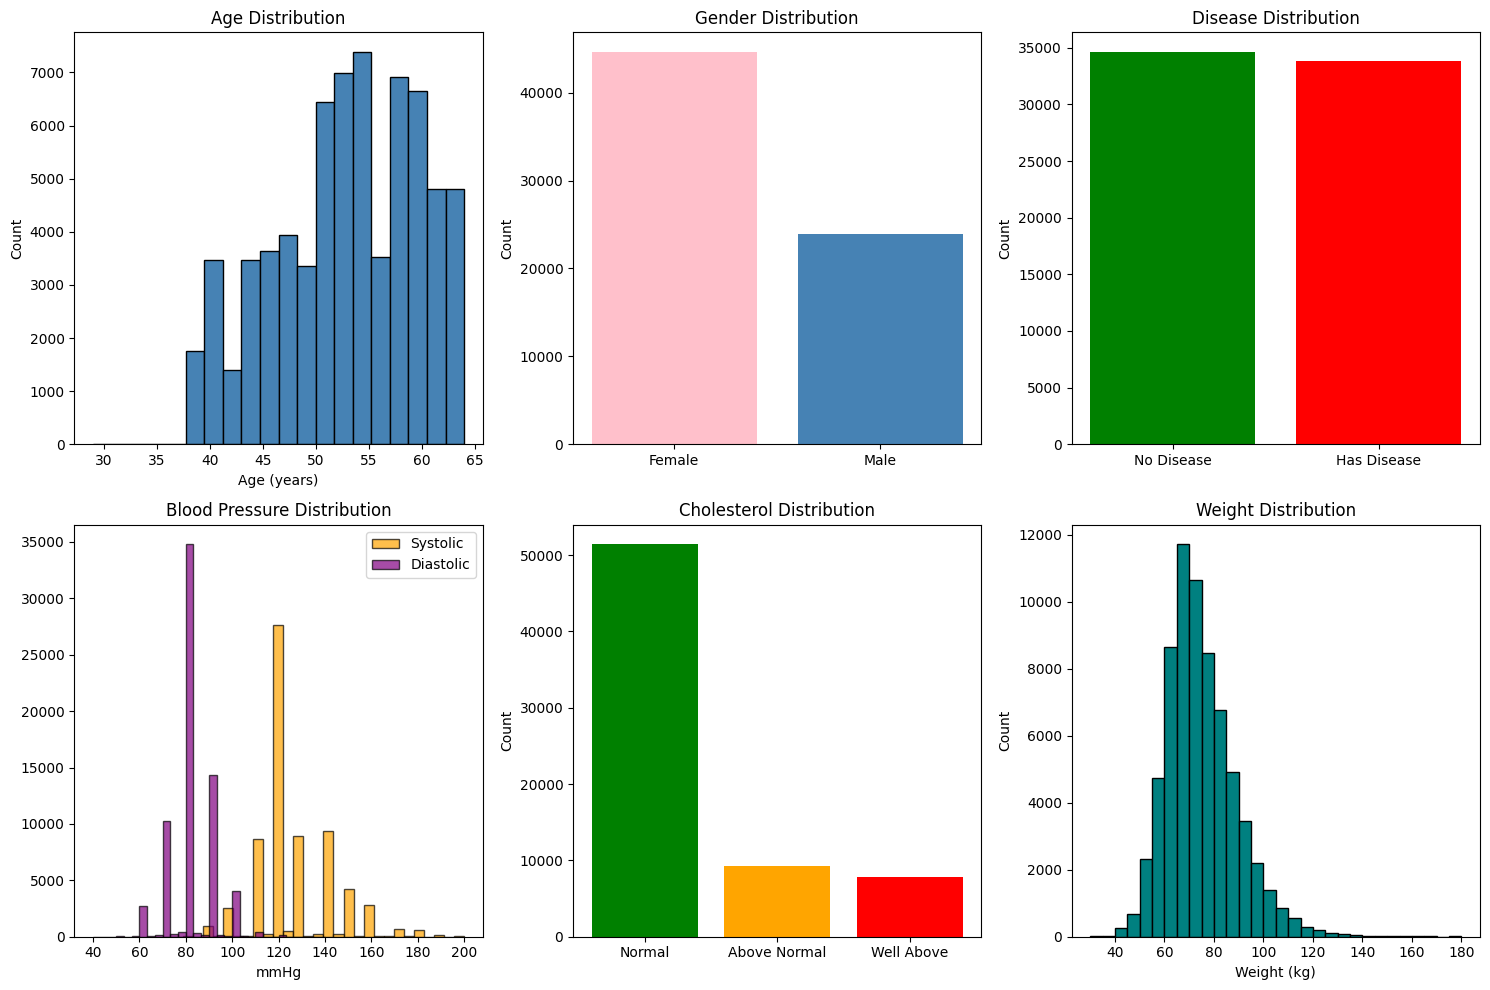

Charts saved!


In [6]:
# Set up the plot style
plt.figure(figsize=(15, 10))

# 1. Age Distribution
plt.subplot(2, 3, 1)
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Count')

# 2. Gender Distribution
plt.subplot(2, 3, 2)
gender_counts = df['gender'].value_counts()
plt.bar(['Female', 'Male'], gender_counts.values, color=['pink', 'steelblue'])
plt.title('Gender Distribution')
plt.ylabel('Count')

# 3. Cardio Disease Distribution
plt.subplot(2, 3, 3)
cardio_counts = df['cardio'].value_counts()
plt.bar(['No Disease', 'Has Disease'], cardio_counts.values, color=['green', 'red'])
plt.title('Disease Distribution')
plt.ylabel('Count')

# 4. Blood Pressure Distribution
plt.subplot(2, 3, 4)
plt.hist(df['ap_hi'], bins=30, color='orange', edgecolor='black', alpha=0.7, label='Systolic')
plt.hist(df['ap_lo'], bins=30, color='purple', edgecolor='black', alpha=0.7, label='Diastolic')
plt.title('Blood Pressure Distribution')
plt.xlabel('mmHg')
plt.legend()

# 5. Cholesterol Distribution
plt.subplot(2, 3, 5)
chol_counts = df['cholesterol'].value_counts()
plt.bar(['Normal', 'Above Normal', 'Well Above'], chol_counts.values, color=['green', 'orange', 'red'])
plt.title('Cholesterol Distribution')
plt.ylabel('Count')

# 6. Weight Distribution
plt.subplot(2, 3, 6)
plt.hist(df['weight'], bins=30, color='teal', edgecolor='black')
plt.title('Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('../data/exploration_charts.png')
plt.show()
print("Charts saved!")

In [7]:
# Save cleaned data for use in next notebook
df.to_csv('../data/cardio_cleaned.csv', index=False)
print("Cleaned dataset saved!")
print("Final shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Cleaned dataset saved!
Final shape: (68517, 12)

Column names:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
